## Data Description:

We collected page flipping video from smart phones and labelled them as flipping and not flipping.

We clipped the videos as short videos and labelled them as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

## Goal(s):

Predict if the page is being flipped using a single image.

## Success Metrics:

Evaluate model performance based on F1 score, the higher the better.

## Current Challenges:

Predict if a given sequence of images contains an action of flipping.

In [2]:
# Import necessary libraries

import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.utils import load_img, img_to_array

## Exploratory Data Analysis

In [4]:
# Set configurations

train_path = os.path.join("images", "training")
test_path = os.path.join("images", "testing")
classes = ["notflip", "flip"]
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
datasets = ["training", "test"]
img_height = 128
img_width = 128
batch_size = 32
epochs = 15
seed = 123

model_path = "page_flip_cnn.keras"
label_map_path = "label_map.json"
best_threshold_path = "best_threshold.json"

In [5]:
# Import image files
def collect_metadata(path):
    records = []
    for class_name in classes:
        class_dir = os.path.join(path, class_name)
        label = classes.index(class_name)
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
        
            # Extract video id and frame number
            stem = os.path.splitext(fname)[0]
            match = re.match(r"(.+)_([0-9]+)$", stem)
            video_id, frame_num = match.group(1), int(match.group(2))

            # Import images
            with Image.open(fpath) as img:
                width, height = img.size
                mode = img.mode
            size_kb = os.path.getsize(fpath) / 1024.0

            # Add data to records
            records.append({"filepath": fpath, "filename": fname, "class_name": class_name, "label": label, "video_id": video_id, 
                            "frame_num": frame_num, "width": width, "height": height, "mode": mode, "file_size_kb": size_kb})

    return pd.DataFrame(records)

In [6]:
# Collect metadata for training dataset

train_md = collect_metadata(train_path)
train_md.shape

(2392, 10)

In [7]:
train_md.head()

,filepath,filename,class_name,label,video_id,frame_num,width,height,mode,file_size_kb
0,images\training\notflip\0001_000000001.jpg,0001_000000001.jpg,notflip,0,0001,1,1080,1920,RGB,349.019531
1,images\training\notflip\0001_000000003.jpg,0001_000000003.jpg,notflip,0,0001,3,1080,1920,RGB,348.999023
2,images\training\notflip\0001_000000005.jpg,0001_000000005.jpg,notflip,0,0001,5,1080,1920,RGB,355.277344
3,images\training\notflip\0001_000000006.jpg,0001_000000006.jpg,notflip,0,0001,6,1080,1920,RGB,358.387695
4,images\training\notflip\0001_000000007.jpg,0001_000000007.jpg,notflip,0,0001,7,1080,1920,RGB,361.309570


In [8]:
train_md.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filepath      2392 non-null   str    
 1   filename      2392 non-null   str    
 2   class_name    2392 non-null   str    
 3   label         2392 non-null   int64  
 4   video_id      2392 non-null   str    
 5   frame_num     2392 non-null   int64  
 6   width         2392 non-null   int64  
 7   height        2392 non-null   int64  
 8   mode          2392 non-null   str    
 9   file_size_kb  2392 non-null   float64
dtypes: float64(1), int64(4), str(5)
memory usage: 187.0 KB


In [9]:
train_md.describe()

,label,frame_num,width,height,file_size_kb
count,2392.000000,2392.000000,2392.0,2392.0,2392.000000
mean,0.485786,16.607441,1080.0,1920.0,310.794751
std,0.499902,8.710656,0.0,0.0,58.478180
min,0.000000,1.000000,1080.0,1920.0,146.525391
25%,0.000000,10.000000,1080.0,1920.0,278.709229
50%,0.000000,17.000000,1080.0,1920.0,313.337402
75%,1.000000,23.000000,1080.0,1920.0,346.815918
max,1.000000,54.000000,1080.0,1920.0,461.351562


All training images same dimensions (width and height)

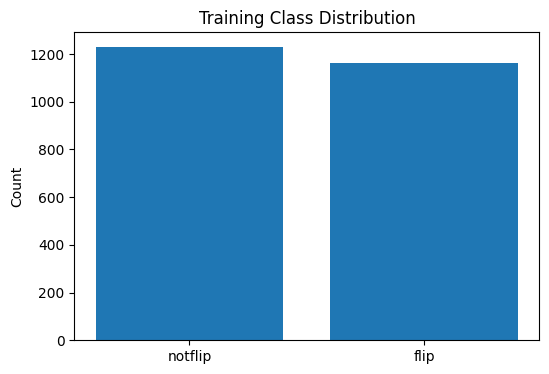

In [11]:
# Plot training class distribution

counts = train_md["class_name"].value_counts().reindex(classes)
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Training Class Distribution")
plt.ylabel("Count")
plt.show()

Training data set is not imbalanced. We can input this data classifier models without further processing.

In [13]:
# Collect metadata for test dataset

test_md = collect_metadata(test_path)
test_md.shape

(597, 10)

In [14]:
test_md.head()

,filepath,filename,class_name,label,video_id,frame_num,width,height,mode,file_size_kb
0,images\testing\notflip\0001_000000002.jpg,0001_000000002.jpg,notflip,0,0001,2,1080,1920,RGB,349.118164
1,images\testing\notflip\0001_000000004.jpg,0001_000000004.jpg,notflip,0,0001,4,1080,1920,RGB,349.021484
2,images\testing\notflip\0001_000000009.jpg,0001_000000009.jpg,notflip,0,0001,9,1080,1920,RGB,365.541016
3,images\testing\notflip\0001_000000014.jpg,0001_000000014.jpg,notflip,0,0001,14,1080,1920,RGB,374.392578
4,images\testing\notflip\0001_000000024.jpg,0001_000000024.jpg,notflip,0,0001,24,1080,1920,RGB,376.479492


In [15]:
test_md.info()

<class 'pandas.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filepath      597 non-null    str    
 1   filename      597 non-null    str    
 2   class_name    597 non-null    str    
 3   label         597 non-null    int64  
 4   video_id      597 non-null    str    
 5   frame_num     597 non-null    int64  
 6   width         597 non-null    int64  
 7   height        597 non-null    int64  
 8   mode          597 non-null    str    
 9   file_size_kb  597 non-null    float64
dtypes: float64(1), int64(4), str(5)
memory usage: 46.8 KB


In [16]:
test_md.describe()

,label,frame_num,width,height,file_size_kb
count,597.000000,597.000000,597.0,597.0,597.000000
mean,0.485762,16.479062,1080.0,1920.0,308.661486
std,0.500216,9.112734,0.0,0.0,63.499224
min,0.000000,1.000000,1080.0,1920.0,140.103516
25%,0.000000,9.000000,1080.0,1920.0,274.908203
50%,0.000000,16.000000,1080.0,1920.0,312.348633
75%,1.000000,23.000000,1080.0,1920.0,351.726562
max,1.000000,55.000000,1080.0,1920.0,457.510742


All training and test image have same dimensions (width and height)

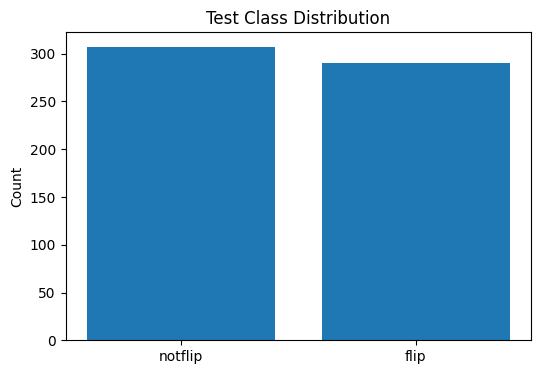

In [18]:
# Plot test class distribution

counts = test_md["class_name"].value_counts().reindex(classes)
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Test Class Distribution")
plt.ylabel("Count")
plt.show()

Test data is also not imbalanced.

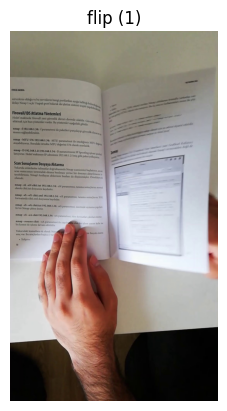

In [20]:
# View image samples from training data

view_dir = Path("images/training")
flip_images = list(view_dir.glob('flip/*.jpg'))    

img = Image.open(flip_images[0])

plt.imshow(img)
plt.title("flip (1)")
plt.axis("off")
plt.show()

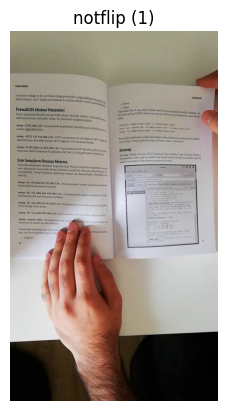

In [21]:
# View image samples from test data

view_dir = Path("images/testing")
notflip_images = list(view_dir.glob('notflip/*.jpg'))    

img = Image.open(notflip_images[0])

plt.imshow(img)
plt.title("notflip (1)")
plt.axis("off")
plt.show()

## Model development

In [23]:
# Set seed

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

In [24]:
# Split the training dataset into training and validation sets

train_data = tf.keras.utils.image_dataset_from_directory(train_path, labels="inferred", label_mode="binary", class_names=classes, 
                                                           validation_split=0.2, subset="training", seed=123, image_size=(img_height, img_width), 
                                                           batch_size=batch_size, shuffle=True)

Found 2392 files belonging to 2 classes.
Using 1914 files for training.


In [25]:
val_data = tf.keras.utils.image_dataset_from_directory(train_path, labels="inferred", label_mode="binary", class_names=classes, 
                                                           validation_split=0.2, subset="validation", seed=123, image_size=(img_height, img_width), 
                                                           batch_size=batch_size, shuffle=True)

Found 2392 files belonging to 2 classes.
Using 478 files for validation.


In [26]:
test_data = tf.keras.utils.image_dataset_from_directory(test_path, labels="inferred", label_mode="binary", class_names=classes, 
                                                        image_size=(img_height, img_width), batch_size=batch_size, shuffle=False)

Found 597 files belonging to 2 classes.


In [27]:
# Flip, rotate, and zoom images for robust training

data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal"), 
                                         layers.RandomRotation(0.05), 
                                         layers.RandomZoom(0.1),], 
                                        name="data_augmentation",)

In [28]:
model = models.Sequential(
        [
            layers.Input(shape=(img_height, img_width, 3)),
            data_augmentation,
            layers.Rescaling(1.0 / 255),

            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.2),

            layers.Dense(1, activation="sigmoid"),
        ]
    )

In [29]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall"),],
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,583,233 (17.48 MB)

 Trainable params: 4,583,233 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
callback_list = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1,
        ),
        callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

In [32]:
history = model.fit(train_data, validation_data=val_data, epochs=epochs, callbacks=callback_list, verbose=1,)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5072 - loss: 0.8099 - precision: 0.4876 - recall: 0.5275
Epoch 1: val_loss improved from None to 0.69220, saving model to page_flip_cnn.keras

Epoch 1: finished saving model to page_flip_cnn.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 348ms/step - accuracy: 0.5042 - loss: 0.7271 - precision: 0.4869 - recall: 0.4213 - val_accuracy: 0.5105 - val_loss: 0.6922 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5260 - loss: 0.6908 - precision: 0.5271 - recall: 0.1268
Epoch 2: val_loss improved from 0.69220 to 0.65530, saving model to page_flip_cnn.keras

Epoch 2: finished saving model to page_flip_cnn.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 387ms/step - accuracy: 0.5298 - loss: 0.6892 - precision: 0.5217 - recall: 0.3631 - val_accuracy: 0.6234 - val_loss: 0.6553 - val_precision: 0.6552 - val_recall: 0.4872 - learning_rate: 0.0010
Epoch 3/15
60/6

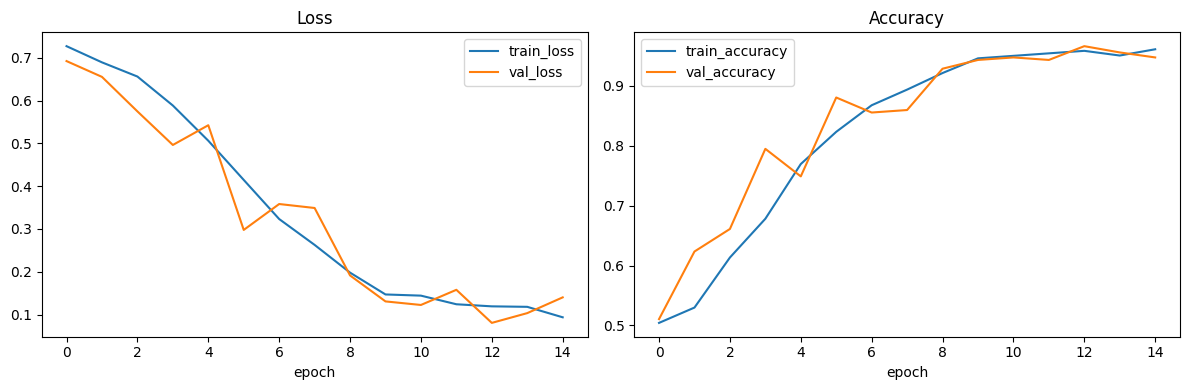

In [33]:
# Plot training history

hist = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist["accuracy"], label="train_accuracy")
plt.plot(hist["val_accuracy"], label="val_accuracy")
plt.xlabel("epoch")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
# Get true and predicted labels for validation data

y_true = []
y_prob = []

for images, labels in val_data:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs.tolist())
    y_true.extend(labels.numpy().ravel().astype(int).tolist())

In [35]:
# Tune threshold

thresholds = np.arange(0.10, 0.91, 0.05)

best_threshold = 0.5
best_f1 = -1.0
results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    score = f1_score(y_true, y_pred)
    results.append((float(t), float(score)))

    if score > best_f1:
        best_f1 = round(score, 4)
        best_threshold = round(float(t),4)

In [36]:
# Best threshold

best_threshold

0.3

In [37]:
# Predict label with best threshold

y_pred = (np.asarray(y_prob) >= best_threshold).astype(int)

In [38]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

     notflip       0.97      0.96      0.97       244
        flip       0.96      0.97      0.97       234

    accuracy                           0.97       478
   macro avg       0.97      0.97      0.97       478
weighted avg       0.97      0.97      0.97       478

Confusion Matrix:
[[235   9]
 [  7 227]]


### Predict if the page is being flipped using a single image

In [40]:
# Load image

idx = 10
image_path = test_md.filepath[idx]
img = load_img(image_path, target_size=(img_height, img_width))
arr = img_to_array(img)
arr = np.expand_dims(arr, axis=0)

In [41]:
# Predict label

prob_flip = round(float(model.predict(arr, verbose=0)[0][0]),4)
pred_label = int(prob_flip >= best_threshold)

prob_flip, pred_label

(0.0127, 0)

In [42]:
test_md.label[idx]

np.int64(0)

Model correctly predicted that the page was not flipped.

### Predict if a given sequence of images contains an action of flipping

In [45]:
# Predict labels for test data

probs_seq = []
preds_seq = []
start_idx = 275
end_idx = 325

for image_path in test_md.filepath[start_idx :end_idx]:
    img = load_img(image_path, target_size=(img_height, img_width))
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    prob_flip = round(float(model.predict(arr, verbose=0)[0][0]),4)
    pred_label = int(prob_flip >= best_threshold)
    probs_seq.append(prob_flip)
    preds_seq.append(pred_label)

In [46]:
# Find true labels and generate classification report

y_true_seq = test_md.label[start_idx :end_idx]

print("\nClassification Report:")
print(classification_report(y_true_seq, preds_seq, target_names=classes))

print("Confusion Matrix:")
print(confusion_matrix(y_true_seq, preds_seq))


Classification Report:
              precision    recall  f1-score   support

     notflip       0.97      0.97      0.97        32
        flip       0.94      0.94      0.94        18

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50

Confusion Matrix:
[[31  1]
 [ 1 17]]


Model performs well on slighlty imbalanced dataset.